# 05. Forecasting

This notebook is the deep-dive offline forecasting benchmark for AirPulse. It is designed to continue after the station universe work is reasonably stable, without forcing a full rerun of notebook 04.

What this notebook does:
- loads the current processed forecasting dataset and existing offline artifacts
- builds a leakage-safe forecasting table for detailed PM2.5 benchmarking
- benchmarks useful next-day forecasting candidates on a common holdout split
- tunes the strongest tree-based candidates and ensembles
- inspects station-level and high-pollution error behavior
- summarizes current champion models across `pm25`, `pm10`, `o3`, and `no2`
- saves reusable offline champion artifacts

Recommended upstream flow:
- `01_Global_Forecast_Error_Reduction_Plan.ipynb`
- `04_Station_Expansion_Eval.ipynb`

Use this notebook after you have either accepted the broader station scope or intentionally stayed with the baseline universe.

Practical note:
- if notebook 04 is expensive to rerun, you can still continue here by using the saved artifact summaries under `artifacts/` and `data/processed/station_expansion/`


## 1. Imports and Paths

In [1]:
from pathlib import Path
import sys
import json
import pickle
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet
from prophet.serialize import model_to_json
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC_ROOT = PROJECT_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from airpulse.forecasting import _holt_winters

DATA_CANDIDATES = [
    PROJECT_ROOT / 'data' / 'processed' / 'featured_dataset.parquet',
    PROJECT_ROOT / 'data' / 'processed' / 'features_dataset.parquet',
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), DATA_CANDIDATES[0])
DAILY_DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'fact_air_quality_daily.parquet'
TRAIN_SCRIPT_PATH = PROJECT_ROOT / 'scripts' / 'train_offline_forecast_models.py'
STATION_RECOMMENDATION_PATH = PROJECT_ROOT / 'data' / 'processed' / 'station_expansion' / 'production_recommendation.csv'
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('PM2.5 feature dataset:', DATA_PATH)
print('Daily station dataset:', DAILY_DATA_PATH)
print('Training script:', TRAIN_SCRIPT_PATH)
print('Station recommendation file:', STATION_RECOMMENDATION_PATH)


2026-03-26 01:29:58.911 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


Project root: C:\Users\rbeyz\Desktop\AirPulse_Global
PM2.5 feature dataset: C:\Users\rbeyz\Desktop\AirPulse_Global\data\processed\featured_dataset.parquet
Daily station dataset: C:\Users\rbeyz\Desktop\AirPulse_Global\data\processed\fact_air_quality_daily.parquet
Training script: C:\Users\rbeyz\Desktop\AirPulse_Global\scripts\train_offline_forecast_models.py
Station recommendation file: C:\Users\rbeyz\Desktop\AirPulse_Global\data\processed\station_expansion\production_recommendation.csv


## Offline Artifact Refresh Helper

This notebook should be used after the manual station CSV universe has been evaluated in `04_Station_Expansion_Eval.ipynb`.

Recommended default:
- put the manually downloaded station histories under `data/processed/observation_cache/`
- finish `04_Station_Expansion_Eval.ipynb` first and confirm the accepted station universe is strong enough
- use `--scope-mode all` so the trainer automatically includes every available daily station
- retrain `pm25`, `pm10`, `o3`, and `no2` together so the app stays in sync


In [2]:
MULTI_POLLUTANT_COMMAND = [
    sys.executable,
    str(TRAIN_SCRIPT_PATH),
    '--scope-mode', 'all',
    '--pollutants', 'pm25', 'pm10', 'o3', 'no2',
]
print('Run this command after notebook 04 confirms the accepted manual station universe:')
print(' '.join(MULTI_POLLUTANT_COMMAND))
# Uncomment to run directly from the notebook:
# subprocess.run(MULTI_POLLUTANT_COMMAND, check=True, cwd=PROJECT_ROOT)


Run this command after notebook 04 confirms the accepted manual station universe:
c:\Users\rbeyz\Desktop\AirPulse_Global\.venv\Scripts\python.exe C:\Users\rbeyz\Desktop\AirPulse_Global\scripts\train_offline_forecast_models.py --scope-mode all --pollutants pm25 pm10 o3 no2


## 2. Current Offline Champion Summary

Before we dive into the PM2.5 deep-dive benchmark, we load the current saved champion summaries for `pm25`, `pm10`, `o3`, and `no2`.

This gives us a fast read on the current production-style winners without rerunning the heavier upstream notebook sections.

In [3]:
summary_rows = []
for pollutant in ['pm25', 'pm10', 'o3', 'no2']:
    metrics_path = ARTIFACT_DIR / f'{pollutant}_next_day_forecast_metrics.json'
    payload = json.loads(metrics_path.read_text(encoding='utf-8')) if metrics_path.exists() else {}
    best_model_name = payload.get('best_model_name', '')
    tournament = payload.get('model_tournament_results') or []
    best_row = next((row for row in tournament if row.get('model') == best_model_name), tournament[0] if tournament else {})

    summary_rows.append({
        'pollutant': pollutant,
        'best_model_name': best_model_name,
        'train_rows': payload.get('train_rows', None),
        'test_rows': payload.get('test_rows', None),
        'rows_used_best_model': best_row.get('rows_used', payload.get('test_rows', None)),
        'mae': best_row.get('MAE', None),
        'rmse': best_row.get('RMSE', None),
        'r2': best_row.get('R2', None),
        'mape': best_row.get('MAPE', None),
        'selected_station_config': payload.get('selected_station_config', ''),
    })

offline_summary_df = pd.DataFrame(summary_rows)
summary_csv_path = ARTIFACT_DIR / 'offline_forecast_metrics_summary.csv'
summary_json_path = ARTIFACT_DIR / 'offline_forecast_metrics_summary.json'
offline_summary_df.to_csv(summary_csv_path, index=False)
summary_json_path.write_text(offline_summary_df.to_json(orient='records', indent=2), encoding='utf-8')
display(offline_summary_df)
print(f'Saved summary artifacts to: {summary_csv_path} and {summary_json_path}')


,pollutant,best_model_name,train_rows,test_rows,rows_used_best_model,mae,rmse,r2,mape,selected_station_config
0,pm25,tree_ensemble_stress_mix,5204,1301,1301,7.872704,11.200218,0.69531,NaN,prophet_additive_short_horizon
1,pm10,random_forest_benchmark,7168,1792,1792,8.321068,12.137332,NaN,28.791209,all_available_stations
2,o3,random_forest_benchmark,7136,1785,1785,3.744914,6.006208,NaN,48.589479,all_available_stations
3,no2,tree_ensemble_stress_mix,7169,1793,1793,5.387035,7.756707,NaN,39.987103,all_available_stations


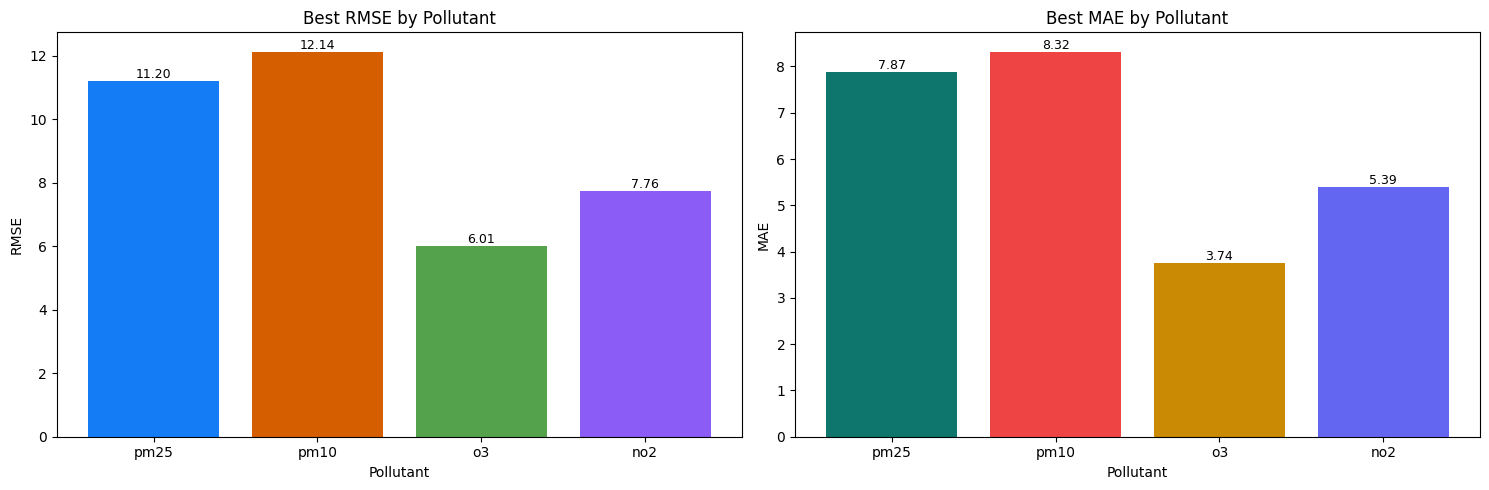

In [4]:
if offline_summary_df.empty:
    print('No offline summary artifacts were found.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    rmse_plot_df = offline_summary_df.dropna(subset=['rmse']).copy()
    rmse_colors = ['#147df5', '#d55e00', '#54a24b', '#8b5cf6'][:len(rmse_plot_df)]
    axes[0].bar(rmse_plot_df['pollutant'], rmse_plot_df['rmse'], color=rmse_colors)
    axes[0].set_title('Best RMSE by Pollutant')
    axes[0].set_xlabel('Pollutant')
    axes[0].set_ylabel('RMSE')
    for idx, value in enumerate(rmse_plot_df['rmse']):
        axes[0].text(idx, value, f'{value:.2f}', ha='center', va='bottom', fontsize=9)

    mae_plot_df = offline_summary_df.dropna(subset=['mae']).copy()
    mae_colors = ['#0f766e', '#ef4444', '#ca8a04', '#6366f1'][:len(mae_plot_df)]
    axes[1].bar(mae_plot_df['pollutant'], mae_plot_df['mae'], color=mae_colors)
    axes[1].set_title('Best MAE by Pollutant')
    axes[1].set_xlabel('Pollutant')
    axes[1].set_ylabel('MAE')
    for idx, value in enumerate(mae_plot_df['mae']):
        axes[1].text(idx, value, f'{value:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


## 3. Load and Inspect the Dataset

In [5]:
df = pd.read_parquet(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['date', 'station_key']).reset_index(drop=True)

print('Shape:', df.shape)
print('Date range:', df['date'].min(), '->', df['date'].max())
print('Station count:', df['station_key'].nunique())
display(df.head())


Shape: (110999, 22)
Date range: 2013-12-31 00:00:00 -> 2026-03-31 00:00:00
Station count: 43


,date,pm25,pm10,o3,no2,so2,co,station_key,pm25_next_day,pm25_lag_1,...,pm25_lag_7,pm25_lag_14,pm25_roll_mean_3,pm25_roll_std_3,pm25_roll_mean_7,pm25_roll_std_7,pm25_roll_mean_14,pm25_roll_std_14,day_of_week,month
0,2013-12-31,NaN,90.0,NaN,17.0,5.0,NaN,alejakrasinskiegokrakowmaopolskaairquality,160.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,12
1,2013-12-31,NaN,5.0,NaN,4.0,NaN,NaN,danmarksplassbergennorwayairquality,17.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,12
2,2013-12-31,NaN,15.0,14.0,7.0,1.0,NaN,kirkeveienoslonorwayairquality,47.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,12
3,2013-12-31,NaN,16.0,29.0,23.0,6.0,4.0,londonairquality,37.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,12
4,2013-12-31,NaN,9.0,23.0,6.0,NaN,NaN,lyoncentreairquality,26.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,12


In [6]:
station_summary = (
    df.groupby('station_key')
    .agg(
        rows=('date', 'size'),
        start=('date', 'min'),
        end=('date', 'max'),
        pm25_non_null=('pm25', lambda s: int(s.notna().sum())),
        pm25_mean=('pm25', 'mean'),
    )
    .sort_values('rows', ascending=False)
)
display(station_summary)

completeness = (df.notna().mean() * 100).round(2).sort_values(ascending=False)
display(completeness.to_frame('non_null_pct').head(20))


,rows,start,end,pm25_non_null,pm25_mean
station_key,,,,,
londonairquality,4448,2013-12-31,2026-03-24,4436,56.556132
danmarksplassbergennorwayairquality,4376,2013-12-31,2026-03-24,4354,27.565457
salfordecclesairquality,4343,2013-12-31,2026-03-24,4306,37.642127
parisairquality,4320,2013-12-31,2026-03-24,4308,60.159935
madridairquality,4270,2013-12-31,2026-02-08,4245,55.031331
alejakrasinskiegokrakowmaopolskaairquality,4235,2013-12-31,2026-03-24,4201,79.440133
marszakowskawarszawamazowieckieairquality,4205,2014-01-01,2026-03-24,4101,68.688856
sternschanzehamburgairquality,4134,2014-08-18,2026-03-24,4065,41.158672
truckeefirestationnevadacaliforniaairquality,4102,2014-01-01,2026-03-23,4096,40.663574


,non_null_pct
date,100.00
station_key,100.00
day_of_week,100.00
pm25_next_day,100.00
month,100.00
pm25_roll_mean_14,99.86
pm25_roll_mean_7,99.82
pm25_roll_std_14,99.78
pm25_roll_std_7,99.69
pm25_roll_mean_3,99.67


## 4. Build the Forecast Modeling Table

The detailed benchmark in this notebook remains centered on `pm25_next_day`, which means each row uses current-day features to predict the next day's PM2.5 value.

This notebook builds a richer station-aware feature table for both time-series and tabular models.

The app can use live weather-linked logic in production. In this offline notebook we keep everything reproducible by working from the local processed feature store only.

Why PM2.5 here?
- PM2.5 is still the most operationally important pollutant for the app's next-day forecast experience
- the multi-pollutant champion summary above gives the cross-pollutant view, while the rest of this notebook stays focused and deep on one target


In [7]:
model_df = df.copy()
model_df = model_df.sort_values(['station_key', 'date']).reset_index(drop=True)
pm25_group = model_df.groupby('station_key')['pm25']
model_df['pm25_lag_21'] = pm25_group.shift(21)
model_df['pm25_lag_28'] = pm25_group.shift(28)
shifted_pm25 = pm25_group.shift(1)
model_df['pm25_roll_mean_21'] = shifted_pm25.groupby(model_df['station_key']).rolling(21, min_periods=10).mean().reset_index(level=0, drop=True)
model_df['pm25_roll_std_21'] = shifted_pm25.groupby(model_df['station_key']).rolling(21, min_periods=10).std().reset_index(level=0, drop=True)
model_df['pm25_roll_min_7'] = shifted_pm25.groupby(model_df['station_key']).rolling(7, min_periods=4).min().reset_index(level=0, drop=True)
model_df['pm25_roll_max_7'] = shifted_pm25.groupby(model_df['station_key']).rolling(7, min_periods=4).max().reset_index(level=0, drop=True)
model_df['pm25_roll_median_7'] = shifted_pm25.groupby(model_df['station_key']).rolling(7, min_periods=4).median().reset_index(level=0, drop=True)
model_df['is_weekend'] = (model_df['day_of_week'] >= 5).astype(int)
model_df['month_sin'] = np.sin(2 * np.pi * model_df['month'] / 12)
model_df['month_cos'] = np.cos(2 * np.pi * model_df['month'] / 12)
model_df['weekday_sin'] = np.sin(2 * np.pi * model_df['day_of_week'] / 7)
model_df['weekday_cos'] = np.cos(2 * np.pi * model_df['day_of_week'] / 7)
model_df['pm25_diff_1_7'] = model_df['pm25_lag_1'] - model_df['pm25_lag_7']
model_df['pm25_diff_7_14'] = model_df['pm25_lag_7'] - model_df['pm25_lag_14']
model_df['pm25_diff_14_28'] = model_df['pm25_lag_14'] - model_df['pm25_lag_28']
model_df['pm25_ratio_1_7'] = model_df['pm25_lag_1'] / (model_df['pm25_lag_7'].abs() + 1)
model_df['pm25_ratio_7_21'] = model_df['pm25_lag_7'] / (model_df['pm25_lag_21'].abs() + 1)
model_df['pm25_roll_range_7_14'] = model_df['pm25_roll_mean_7'] - model_df['pm25_roll_mean_14']
model_df['pm25_roll_spread_7'] = model_df['pm25_roll_max_7'] - model_df['pm25_roll_min_7']
model_df['pm25_volatility_ratio'] = model_df['pm25_roll_std_7'] / (model_df['pm25_roll_mean_7'].abs() + 1)
model_df['pm25_trend_strength'] = (model_df['pm25_lag_1'] - model_df['pm25_lag_21']) / 20.0
model_df['pm25_high_pollution_lag1'] = (model_df['pm25_lag_1'] >= 55).astype(int)
model_df['pm25_high_pollution_lag7'] = (model_df['pm25_lag_7'] >= 55).astype(int)
worst_station_keys = {
    'maslakairquality',
    'istanbulesenyurtairquality',
    'istanbulalibeykoyairquality',
    'istanbulkagithaneairquality',
}
model_df['worst_station_flag'] = model_df['station_key'].isin(worst_station_keys).astype(int)
model_df['winter_flag'] = model_df['month'].isin([11, 12, 1, 2]).astype(int)
model_df['worst_station_high_pollution_flag'] = model_df['worst_station_flag'] * model_df['pm25_high_pollution_lag1']
model_df['winter_high_pollution_flag'] = model_df['winter_flag'] * model_df['pm25_high_pollution_lag1']
model_df['station_code'] = model_df['station_key'].astype('category').cat.codes
model_df['days_since_start'] = (pd.to_datetime(model_df['date']) - pd.to_datetime(model_df['date']).min()).dt.days

feature_cols = [
    'pm25', 'pm10', 'o3', 'no2', 'so2', 'co',
    'pm25_lag_1', 'pm25_lag_7', 'pm25_lag_14', 'pm25_lag_21', 'pm25_lag_28',
    'pm25_roll_mean_3', 'pm25_roll_std_3',
    'pm25_roll_mean_7', 'pm25_roll_std_7',
    'pm25_roll_mean_14', 'pm25_roll_std_14',
    'pm25_roll_mean_21', 'pm25_roll_std_21',
    'pm25_roll_min_7', 'pm25_roll_max_7', 'pm25_roll_median_7',
    'day_of_week', 'month',
    'is_weekend', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos',
    'pm25_diff_1_7', 'pm25_diff_7_14', 'pm25_diff_14_28',
    'pm25_ratio_1_7', 'pm25_ratio_7_21',
    'pm25_roll_range_7_14', 'pm25_roll_spread_7', 'pm25_volatility_ratio',
    'pm25_trend_strength', 'pm25_high_pollution_lag1', 'pm25_high_pollution_lag7',
    'worst_station_flag', 'winter_flag', 'worst_station_high_pollution_flag', 'winter_high_pollution_flag',
]
tree_feature_cols = feature_cols + ['station_code', 'days_since_start']
target_col = 'pm25_next_day'

model_df = model_df.dropna(subset=[target_col] + tree_feature_cols).copy()
model_df = model_df.sort_values('date').reset_index(drop=True)
model_df = model_df.rename(columns={'date': 'ds', target_col: 'y'})

split_idx = int(len(model_df) * 0.80)
train_df = model_df.iloc[:split_idx].copy().reset_index(drop=True)
test_df = model_df.iloc[split_idx:].copy().reset_index(drop=True)

print('Usable rows:', len(model_df))
print('Train rows:', len(train_df))
print('Test rows:', len(test_df))
print('Train end:', train_df['ds'].max())
print('Test start:', test_df['ds'].min())
print('Prophet features:', len(feature_cols))
print('Tree features:', len(tree_feature_cols))


Usable rows: 20744
Train rows: 16595
Test rows: 4149
Train end: 2024-06-15 00:00:00
Test start: 2024-06-16 00:00:00
Prophet features: 44
Tree features: 46


## 4. Baseline

We use `pm25_lag_1` as the baseline. This acts like a persistence forecast: tomorrow is assumed to be similar to today's PM2.5.


In [8]:
def regression_metrics(y_true, y_pred):
    metric_df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred}).dropna()
    rmse = mean_squared_error(metric_df['y_true'], metric_df['y_pred']) ** 0.5
    return {
        'rows_used': int(len(metric_df)),
        'MAE': float(mean_absolute_error(metric_df['y_true'], metric_df['y_pred'])),
        'RMSE': float(rmse),
        'R2': float(r2_score(metric_df['y_true'], metric_df['y_pred'])),
    }

baseline_pred = test_df['pm25_lag_1']
baseline_metrics = regression_metrics(test_df['y'], baseline_pred)
baseline_metrics


{'rows_used': 4149,
 'MAE': 21.454326343697275,
 'RMSE': 30.149686819749803,
 'R2': 0.2141338767747033}

## 5. Prophet Candidate Sweep

Instead of locking the notebook to one Prophet setup, we evaluate a small group of reasonable short-horizon candidates and keep the one with the best holdout RMSE.

This gives us a lightweight tuning loop before we move to heavier rolling validation or alternative models.

In [9]:
prophet_candidates = [
    {
        'name': 'prophet_additive_short_horizon',
        'daily_seasonality': False,
        'weekly_seasonality': True,
        'yearly_seasonality': False,
        'seasonality_mode': 'additive',
        'changepoint_prior_scale': 0.06,
        'seasonality_prior_scale': 12.0,
        'interval_width': 0.90,
    },
    {
        'name': 'prophet_additive_smoother_trend',
        'daily_seasonality': False,
        'weekly_seasonality': True,
        'yearly_seasonality': False,
        'seasonality_mode': 'additive',
        'changepoint_prior_scale': 0.03,
        'seasonality_prior_scale': 10.0,
        'interval_width': 0.90,
    },
    {
        'name': 'prophet_additive_more_flexible',
        'daily_seasonality': False,
        'weekly_seasonality': True,
        'yearly_seasonality': False,
        'seasonality_mode': 'additive',
        'changepoint_prior_scale': 0.12,
        'seasonality_prior_scale': 12.0,
        'interval_width': 0.90,
    },
    {
        'name': 'prophet_additive_yearly',
        'daily_seasonality': False,
        'weekly_seasonality': True,
        'yearly_seasonality': True,
        'seasonality_mode': 'additive',
        'changepoint_prior_scale': 0.06,
        'seasonality_prior_scale': 12.0,
        'interval_width': 0.90,
    },
    {
        'name': 'prophet_multiplicative_compact',
        'daily_seasonality': False,
        'weekly_seasonality': True,
        'yearly_seasonality': False,
        'seasonality_mode': 'multiplicative',
        'changepoint_prior_scale': 0.05,
        'seasonality_prior_scale': 8.0,
        'interval_width': 0.90,
    },
]

def fit_prophet_candidate(train_df, test_df, feature_cols, candidate_config):
    prophet_kwargs = {k: v for k, v in candidate_config.items() if k != 'name'}
    model = Prophet(**prophet_kwargs)
    for col in feature_cols:
        model.add_regressor(col)
    model.fit(train_df[['ds', 'y'] + feature_cols])
    forecast = model.predict(test_df[['ds'] + feature_cols]).reset_index(drop=True)

    candidate_test_df = test_df.copy()
    candidate_test_df['yhat'] = forecast['yhat'].clip(lower=0).to_numpy()
    candidate_test_df['yhat_lower'] = forecast['yhat_lower'].clip(lower=0).to_numpy()
    candidate_test_df['yhat_upper'] = forecast['yhat_upper'].clip(lower=0).to_numpy()
    metrics = regression_metrics(candidate_test_df['y'], candidate_test_df['yhat'])
    return model, candidate_test_df, metrics

prophet_candidate_results = []
for candidate in prophet_candidates:
    model, candidate_test_df, metrics = fit_prophet_candidate(train_df, test_df, feature_cols, candidate)
    prophet_candidate_results.append({
        'name': candidate['name'],
        'config': candidate.copy(),
        'model': model,
        'test_df': candidate_test_df,
        'metrics': metrics,
    })

tuning_results_df = pd.DataFrame([
    {
        'candidate': result['name'],
        **result['metrics'],
        'seasonality_mode': result['config']['seasonality_mode'],
        'weekly_seasonality': result['config']['weekly_seasonality'],
        'yearly_seasonality': result['config']['yearly_seasonality'],
        'changepoint_prior_scale': result['config']['changepoint_prior_scale'],
        'seasonality_prior_scale': result['config']['seasonality_prior_scale'],
    }
    for result in prophet_candidate_results
]).sort_values(['RMSE', 'MAE']).reset_index(drop=True)

best_prophet_result = min(
    prophet_candidate_results,
    key=lambda result: (result['metrics']['RMSE'], result['metrics']['MAE'])
)
best_prophet_name = best_prophet_result['name']
best_prophet_config = best_prophet_result['config'].copy()
prophet_model = best_prophet_result['model']
test_df = best_prophet_result['test_df'].copy()
prophet_metrics = best_prophet_result['metrics']

display(tuning_results_df)
print(f"Selected Prophet candidate: {best_prophet_name}")
prophet_metrics


01:30:03 - cmdstanpy - INFO - Chain [1] start processing
01:30:10 - cmdstanpy - INFO - Chain [1] done processing
01:30:14 - cmdstanpy - INFO - Chain [1] start processing
01:30:23 - cmdstanpy - INFO - Chain [1] done processing
01:30:28 - cmdstanpy - INFO - Chain [1] start processing
01:30:37 - cmdstanpy - INFO - Chain [1] done processing
01:30:44 - cmdstanpy - INFO - Chain [1] start processing
01:30:56 - cmdstanpy - INFO - Chain [1] done processing
01:31:01 - cmdstanpy - INFO - Chain [1] start processing
01:31:19 - cmdstanpy - INFO - Chain [1] done processing


,candidate,rows_used,MAE,RMSE,R2,seasonality_mode,weekly_seasonality,yearly_seasonality,changepoint_prior_scale,seasonality_prior_scale
0,prophet_additive_smoother_trend,4149,25.878718,35.863624,-0.111966,additive,True,False,0.03,10.0
1,prophet_additive_short_horizon,4149,25.952101,35.922608,-0.115626,additive,True,False,0.06,12.0
2,prophet_additive_yearly,4149,26.030632,35.963996,-0.118198,additive,True,True,0.06,12.0
3,prophet_additive_more_flexible,4149,26.135271,36.073927,-0.125045,additive,True,False,0.12,12.0
4,prophet_multiplicative_compact,4149,27.438544,38.512875,-0.282315,multiplicative,True,False,0.05,8.0


Selected Prophet candidate: prophet_additive_smoother_trend


{'rows_used': 4149,
 'MAE': 25.878717827015183,
 'RMSE': 35.8636244394028,
 'R2': -0.11196550073029687}

## 5B. Model Tournament and Tree Tuning

Instead of betting on one model family, we benchmark multiple candidates on the same holdout split and let the best score win.

Included here:
- main optimization path: Random Forest, Gradient Boosting, HistGradientBoosting, and tree ensembles
- lightweight anchor: Ridge
- compact references: Prophet and station-level pure-series Holt-Winters

Tree-based models are trained on a `log1p` target and converted back to the original PM2.5 scale.

This section is intentionally narrower now: weak model families were removed so the notebook focuses on the candidates that can realistically improve score.

The latest pass also adds stress-weighted variants so we can push the model harder on difficult stations and high-pollution regimes.

In [10]:
def fit_tabular_model(model_name, model, train_df, test_df, feature_cols, log_target=False, sample_weight=None):
    y_train = np.log1p(train_df['y']) if log_target else train_df['y']
    fit_kwargs = {}
    if sample_weight is not None:
        fit_kwargs['sample_weight'] = sample_weight
    model.fit(train_df[feature_cols], y_train, **fit_kwargs)
    raw_pred = model.predict(test_df[feature_cols])
    y_pred = np.expm1(raw_pred) if log_target else raw_pred
    y_pred = np.clip(y_pred, 0, None)

    pred_df = test_df[['ds', 'station_key', 'y']].copy()
    pred_df['yhat'] = y_pred
    pred_df['yhat_lower'] = y_pred
    pred_df['yhat_upper'] = y_pred
    metrics = regression_metrics(pred_df['y'], pred_df['yhat'])
    return {'name': model_name, 'model': model, 'pred_df': pred_df, 'metrics': metrics}

def run_tuned_candidates(base_name, base_model, param_grid, train_df, test_df, feature_cols, log_target=True, sample_weight=None, suffix='tuned'):
    tuned_results = []
    for idx, params in enumerate(param_grid, start=1):
        candidate_name = f"{base_name}_{suffix}_{idx}"
        tuned_model = clone(base_model).set_params(**params)
        tuned_results.append(
            fit_tabular_model(candidate_name, tuned_model, train_df, test_df, feature_cols, log_target=log_target, sample_weight=sample_weight)
        )
    return tuned_results

def build_ensemble_result(model_name, result_lookup, component_names, weights=None):
    if not component_names:
        raise ValueError('component_names must not be empty')
    if weights is None:
        weights = [1 / len(component_names)] * len(component_names)
    base_pred_df = result_lookup[component_names[0]]['pred_df'][['ds', 'station_key', 'y']].copy()
    ensemble_pred = np.zeros(len(base_pred_df), dtype=float)
    for weight, name in zip(weights, component_names):
        ensemble_pred += weight * result_lookup[name]['pred_df']['yhat'].to_numpy(dtype=float)
    base_pred_df['yhat'] = np.clip(ensemble_pred, 0, None)
    base_pred_df['yhat_lower'] = base_pred_df['yhat']
    base_pred_df['yhat_upper'] = base_pred_df['yhat']
    metrics = regression_metrics(base_pred_df['y'], base_pred_df['yhat'])
    return {'name': model_name, 'model': {'type': 'weighted_ensemble', 'components': component_names, 'weights': weights}, 'pred_df': base_pred_df, 'metrics': metrics}

tabular_candidates = [
    ('ridge_benchmark', Ridge(alpha=2.0), False),
    ('random_forest_benchmark', RandomForestRegressor(n_estimators=500, max_depth=18, min_samples_leaf=2, max_features='sqrt', random_state=42, n_jobs=-1), True),
    ('gradient_boosting_benchmark', GradientBoostingRegressor(random_state=42, n_estimators=300, learning_rate=0.05, max_depth=3), True),
    ('hist_gradient_boosting_benchmark', HistGradientBoostingRegressor(random_state=42, max_depth=8, learning_rate=0.05, max_iter=400, min_samples_leaf=20), True),
]

tabular_results = [
    fit_tabular_model(name, model, train_df, test_df, tree_feature_cols, log_target=log_target)
    for name, model, log_target in tabular_candidates
]

high_pollution_weights = np.where(train_df['y'] >= 55, 2.5, 1.0)
station_focus_weights = np.where(train_df['worst_station_flag'] == 1, 1.5, 1.0)
winter_focus_weights = np.where(train_df['winter_flag'] == 1, 1.2, 1.0)
stress_focus_weights = high_pollution_weights * station_focus_weights * winter_focus_weights
tuned_candidate_results = []
tuned_candidate_results.extend(run_tuned_candidates(
    'random_forest_benchmark',
    RandomForestRegressor(random_state=42, n_jobs=-1),
    [
        {'n_estimators': 400, 'max_depth': 16, 'min_samples_leaf': 2, 'max_features': 'sqrt'},
        {'n_estimators': 700, 'max_depth': 20, 'min_samples_leaf': 1, 'max_features': 0.7},
    ],
    train_df,
    test_df,
    tree_feature_cols,
    log_target=True,
))
tuned_candidate_results.extend(run_tuned_candidates(
    'gradient_boosting_benchmark',
    GradientBoostingRegressor(random_state=42),
    [
        {'n_estimators': 400, 'learning_rate': 0.03, 'max_depth': 2, 'subsample': 0.9},
        {'n_estimators': 500, 'learning_rate': 0.04, 'max_depth': 2, 'subsample': 1.0},
    ],
    train_df,
    test_df,
    tree_feature_cols,
    log_target=True,
))
tuned_candidate_results.extend(run_tuned_candidates(
    'hist_gradient_boosting_benchmark',
    HistGradientBoostingRegressor(random_state=42),
    [
        {'learning_rate': 0.03, 'max_depth': 6, 'max_iter': 500, 'min_samples_leaf': 15, 'l2_regularization': 0.0},
        {'learning_rate': 0.04, 'max_depth': 8, 'max_iter': 500, 'min_samples_leaf': 12, 'l2_regularization': 0.1},
    ],
    train_df,
    test_df,
    tree_feature_cols,
    log_target=True,
))
weighted_candidate_results = []
weighted_candidate_results.extend(run_tuned_candidates(
    'gradient_boosting_benchmark',
    GradientBoostingRegressor(random_state=42),
    [
        {'n_estimators': 500, 'learning_rate': 0.04, 'max_depth': 2, 'subsample': 1.0},
    ],
    train_df,
    test_df,
    tree_feature_cols,
    log_target=True,
    sample_weight=high_pollution_weights,
    suffix='weighted',
))
weighted_candidate_results.extend(run_tuned_candidates(
    'hist_gradient_boosting_benchmark',
    HistGradientBoostingRegressor(random_state=42),
    [
        {'learning_rate': 0.04, 'max_depth': 8, 'max_iter': 500, 'min_samples_leaf': 12, 'l2_regularization': 0.1},
    ],
    train_df,
    test_df,
    tree_feature_cols,
    log_target=True,
    sample_weight=high_pollution_weights,
    suffix='weighted',
))
weighted_candidate_results.extend(run_tuned_candidates(
    'gradient_boosting_benchmark',
    GradientBoostingRegressor(random_state=42),
    [
        {'n_estimators': 550, 'learning_rate': 0.035, 'max_depth': 2, 'subsample': 0.95},
    ],
    train_df,
    test_df,
    tree_feature_cols,
    log_target=True,
    sample_weight=stress_focus_weights,
    suffix='stress_weighted',
))
weighted_candidate_results.extend(run_tuned_candidates(
    'hist_gradient_boosting_benchmark',
    HistGradientBoostingRegressor(random_state=42),
    [
        {'learning_rate': 0.035, 'max_depth': 8, 'max_iter': 550, 'min_samples_leaf': 10, 'l2_regularization': 0.1},
    ],
    train_df,
    test_df,
    tree_feature_cols,
    log_target=True,
    sample_weight=stress_focus_weights,
    suffix='stress_weighted',
))

all_tabular_results = tabular_results + tuned_candidate_results + weighted_candidate_results
model_tournament_results = {result['name']: result for result in all_tabular_results}

ensemble_candidates = []
if all(name in model_tournament_results for name in ['gradient_boosting_benchmark_tuned_2', 'random_forest_benchmark_tuned_2', 'hist_gradient_boosting_benchmark_tuned_1']):
    ensemble_candidates.append(build_ensemble_result(
        'tree_ensemble_diverse',
        model_tournament_results,
        ['gradient_boosting_benchmark_tuned_2', 'random_forest_benchmark_tuned_2', 'hist_gradient_boosting_benchmark_tuned_1'],
        [0.5, 0.3, 0.2],
    ))
if all(name in model_tournament_results for name in ['gradient_boosting_benchmark_tuned_1', 'gradient_boosting_benchmark_tuned_2']):
    ensemble_candidates.append(build_ensemble_result(
        'tree_ensemble_gradient_pair',
        model_tournament_results,
        ['gradient_boosting_benchmark_tuned_1', 'gradient_boosting_benchmark_tuned_2'],
        [0.4, 0.6],
    ))
if all(name in model_tournament_results for name in ['gradient_boosting_benchmark_tuned_2', 'gradient_boosting_benchmark_stress_weighted_1', 'random_forest_benchmark_tuned_2']):
    ensemble_candidates.append(build_ensemble_result(
        'tree_ensemble_stress_mix',
        model_tournament_results,
        ['gradient_boosting_benchmark_tuned_2', 'gradient_boosting_benchmark_stress_weighted_1', 'random_forest_benchmark_tuned_2'],
        [0.45, 0.35, 0.20],
    ))
for result in ensemble_candidates:
    model_tournament_results[result['name']] = result

rf_result = next(result for result in all_tabular_results if result['name'] == 'random_forest_benchmark')
rf_model = rf_result['model']
rf_test_df = rf_result['pred_df'].copy()
rf_metrics = rf_result['metrics']

tournament_preview_df = pd.DataFrame([
    {'model': name, **result['metrics']}
    for name, result in model_tournament_results.items()
]).sort_values(['RMSE', 'MAE']).reset_index(drop=True)
top_tree_tuning_df = tournament_preview_df[
    tournament_preview_df['model'].str.contains('random_forest|gradient_boosting|hist_gradient|ensemble', regex=True)
].reset_index(drop=True)
display(top_tree_tuning_df.head(20))
display(tournament_preview_df)
tournament_preview_df.head(1)


,model,rows_used,MAE,RMSE,R2
0,tree_ensemble_diverse,4149,10.649211,16.274952,0.771007
1,hist_gradient_boosting_benchmark_tuned_1,4149,10.757868,16.340180,0.769168
2,hist_gradient_boosting_benchmark_weighted_1,4149,10.735464,16.351277,0.768854
3,tree_ensemble_stress_mix,4149,10.703093,16.364345,0.768484
4,gradient_boosting_benchmark_weighted_1,4149,10.772795,16.378042,0.768097
5,gradient_boosting_benchmark,4149,10.666822,16.446729,0.766147
6,hist_gradient_boosting_benchmark_tuned_2,4149,10.852552,16.484989,0.765058
7,gradient_boosting_benchmark_tuned_2,4149,10.861174,16.489153,0.764940
8,gradient_boosting_benchmark_stress_weighted_1,4149,10.822847,16.529341,0.763792
9,tree_ensemble_gradient_pair,4149,10.981310,16.680207,0.759461


,model,rows_used,MAE,RMSE,R2
0,tree_ensemble_diverse,4149,10.649211,16.274952,0.771007
1,hist_gradient_boosting_benchmark_tuned_1,4149,10.757868,16.340180,0.769168
2,hist_gradient_boosting_benchmark_weighted_1,4149,10.735464,16.351277,0.768854
3,tree_ensemble_stress_mix,4149,10.703093,16.364345,0.768484
4,gradient_boosting_benchmark_weighted_1,4149,10.772795,16.378042,0.768097
5,gradient_boosting_benchmark,4149,10.666822,16.446729,0.766147
6,hist_gradient_boosting_benchmark_tuned_2,4149,10.852552,16.484989,0.765058
7,gradient_boosting_benchmark_tuned_2,4149,10.861174,16.489153,0.764940
8,gradient_boosting_benchmark_stress_weighted_1,4149,10.822847,16.529341,0.763792
9,tree_ensemble_gradient_pair,4149,10.981310,16.680207,0.759461


,model,rows_used,MAE,RMSE,R2
0,tree_ensemble_diverse,4149,10.649211,16.274952,0.771007


## 5C. Per-Model Results

This block prints each model on its own line with the same metric format so the tournament is easier to scan.

The tuned tree candidates are included here as first-class competitors, not as a side note.

In [11]:
per_model_results_df = pd.DataFrame.from_dict(comparison_rows, orient='index') if 'comparison_rows' in locals() else tournament_preview_df.set_index('model')
per_model_results_df = per_model_results_df.sort_values(['RMSE', 'MAE']).reset_index().rename(columns={'index': 'model'})
display(per_model_results_df)

for row in per_model_results_df.to_dict(orient='records'):
    print(f"{row['model']}: MAE={row['MAE']:.3f} | RMSE={row['RMSE']:.3f} | R2={row['R2']:.3f} | rows={int(row['rows_used'])}")


,model,rows_used,MAE,RMSE,R2
0,tree_ensemble_diverse,4149,10.649211,16.274952,0.771007
1,hist_gradient_boosting_benchmark_tuned_1,4149,10.757868,16.340180,0.769168
2,hist_gradient_boosting_benchmark_weighted_1,4149,10.735464,16.351277,0.768854
3,tree_ensemble_stress_mix,4149,10.703093,16.364345,0.768484
4,gradient_boosting_benchmark_weighted_1,4149,10.772795,16.378042,0.768097
5,gradient_boosting_benchmark,4149,10.666822,16.446729,0.766147
6,hist_gradient_boosting_benchmark_tuned_2,4149,10.852552,16.484989,0.765058
7,gradient_boosting_benchmark_tuned_2,4149,10.861174,16.489153,0.764940
8,gradient_boosting_benchmark_stress_weighted_1,4149,10.822847,16.529341,0.763792
9,tree_ensemble_gradient_pair,4149,10.981310,16.680207,0.759461


tree_ensemble_diverse: MAE=10.649 | RMSE=16.275 | R2=0.771 | rows=4149
hist_gradient_boosting_benchmark_tuned_1: MAE=10.758 | RMSE=16.340 | R2=0.769 | rows=4149
hist_gradient_boosting_benchmark_weighted_1: MAE=10.735 | RMSE=16.351 | R2=0.769 | rows=4149
tree_ensemble_stress_mix: MAE=10.703 | RMSE=16.364 | R2=0.768 | rows=4149
gradient_boosting_benchmark_weighted_1: MAE=10.773 | RMSE=16.378 | R2=0.768 | rows=4149
gradient_boosting_benchmark: MAE=10.667 | RMSE=16.447 | R2=0.766 | rows=4149
hist_gradient_boosting_benchmark_tuned_2: MAE=10.853 | RMSE=16.485 | R2=0.765 | rows=4149
gradient_boosting_benchmark_tuned_2: MAE=10.861 | RMSE=16.489 | R2=0.765 | rows=4149
gradient_boosting_benchmark_stress_weighted_1: MAE=10.823 | RMSE=16.529 | R2=0.764 | rows=4149
tree_ensemble_gradient_pair: MAE=10.981 | RMSE=16.680 | R2=0.759 | rows=4149
hist_gradient_boosting_benchmark_stress_weighted_1: MAE=10.896 | RMSE=16.685 | R2=0.759 | rows=4149
hist_gradient_boosting_benchmark: MAE=11.192 | RMSE=16.733 |

## 5D. Model Tournament Snapshot

This quick visual summary makes the tournament easier to scan before we lock the final champion.

The left chart ranks RMSE, and the right chart shows MAE for the same top candidates.

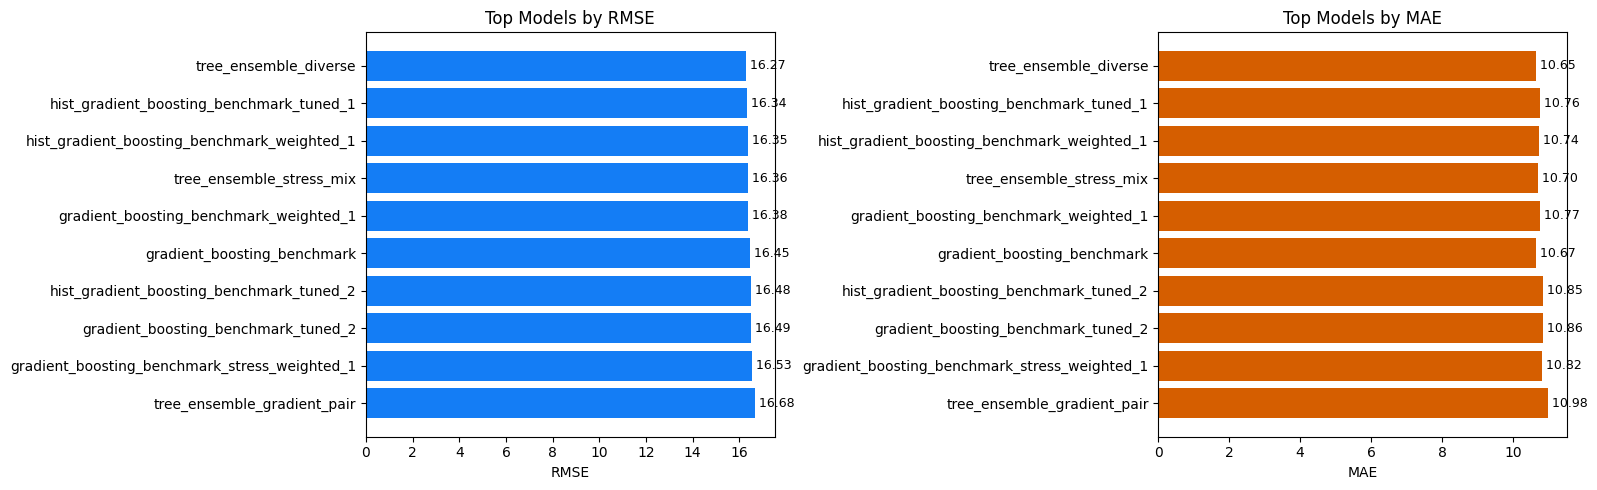

In [12]:
if 'per_model_results_df' not in globals() or per_model_results_df.empty:
    print('Run the per-model results cell first.')
else:
    chart_df = per_model_results_df.head(10).copy()
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].barh(chart_df['model'], chart_df['RMSE'], color='#147df5')
    axes[0].invert_yaxis()
    axes[0].set_title('Top Models by RMSE')
    axes[0].set_xlabel('RMSE')
    for idx, value in enumerate(chart_df['RMSE']):
        axes[0].text(value, idx, f' {value:.2f}', va='center', fontsize=9)

    axes[1].barh(chart_df['model'], chart_df['MAE'], color='#d55e00')
    axes[1].invert_yaxis()
    axes[1].set_title('Top Models by MAE')
    axes[1].set_xlabel('MAE')
    for idx, value in enumerate(chart_df['MAE']):
        axes[1].text(value, idx, f' {value:.2f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()


## 5E. Champion Model

The champion is selected by the lowest holdout RMSE. This cell makes the winner explicit after the full comparison table.

This is the model we currently treat as the offline winner for the dataset and split used in this notebook.

In [13]:
champion_row = per_model_results_df.iloc[0]
champion_summary = pd.DataFrame([
    {
        'Champion Model': champion_row['model'],
        'MAE': round(float(champion_row['MAE']), 3),
        'RMSE': round(float(champion_row['RMSE']), 3),
        'R2': round(float(champion_row['R2']), 3),
        'Rows Used': int(champion_row['rows_used']),
    }
])
display(champion_summary)
print(f"Champion Model: {champion_row['model']}")
print(f"Champion RMSE: {champion_row['RMSE']:.3f}")
print(f"Champion MAE: {champion_row['MAE']:.3f}")
print(f"Champion R2: {champion_row['R2']:.3f}")


,Champion Model,MAE,RMSE,R2,Rows Used
0,tree_ensemble_diverse,10.649,16.275,0.771,4149


Champion Model: tree_ensemble_diverse
Champion RMSE: 16.275
Champion MAE: 10.649
Champion R2: 0.771


## 5F. Holt-Winters Pure-Series Reference

The Streamlit app can still compare Prophet against Holt-Winters on recent holdout performance before deciding which model to trust more for a given run.

Notebook note: the benchmark below is now kept intentionally simple and station-specific. Holt-Winters is run on each station's own historical target series without feature inputs.

We keep it in the notebook because it remains an important fallback reference, but it is no longer part of the main score-improvement path.

In [14]:
holt_frames = []
for station_key, station_train_df in train_df.groupby('station_key'):
    station_train_df = station_train_df.sort_values('ds').reset_index(drop=True)
    station_test_df = test_df[test_df['station_key'] == station_key].sort_values('ds').reset_index(drop=True)
    if station_test_df.empty:
        continue

    series = station_train_df['y'].to_numpy(dtype=float)
    horizon = len(station_test_df)
    if len(series) >= 14:
        station_values, station_upper, station_lower = _holt_winters(series, horizon, season_len=7)
    else:
        last_val = float(series[-1]) if len(series) else 0.0
        station_values = np.repeat(last_val, horizon)
        station_upper = station_values
        station_lower = station_values

    station_pred_df = station_test_df[['ds', 'y', 'station_key']].copy()
    station_pred_df['yhat'] = np.clip(station_values, 0, None)
    station_pred_df['yhat_lower'] = np.clip(station_lower, 0, None)
    station_pred_df['yhat_upper'] = np.clip(station_upper, 0, None)
    holt_frames.append(station_pred_df)

holt_test_df = pd.concat(holt_frames, ignore_index=True) if holt_frames else test_df[['ds', 'y', 'station_key']].assign(yhat=np.nan, yhat_lower=np.nan, yhat_upper=np.nan)
holt_metrics = regression_metrics(holt_test_df['y'], holt_test_df['yhat'])
holt_metrics


{'rows_used': 4149,
 'MAE': 92.71213492024614,
 'RMSE': 143.5483508043673,
 'R2': -16.81473522600755}

In [15]:
comparison_rows = {
    'baseline_pm25_lag_1': baseline_metrics,
    'holt_winters_benchmark': holt_metrics,
    'prophet_regressor_model': prophet_metrics,
}
comparison_rows.update({name: result['metrics'] for name, result in model_tournament_results.items()})
comparison_df = pd.DataFrame.from_dict(comparison_rows, orient='index')
best_model_name = comparison_df.sort_values('RMSE').index[0]
comparison_df['selected_for_app_style_routing'] = comparison_df.index == best_model_name
display(comparison_df)

selected_model_lookup = {
    'prophet_regressor_model': (
        test_df[['ds', 'station_key', 'y', 'yhat', 'yhat_lower', 'yhat_upper']].copy(),
        f'Prophet Forecast ({best_prophet_name})',
    ),
    'holt_winters_benchmark': (
        holt_test_df[['ds', 'station_key', 'y', 'yhat', 'yhat_lower', 'yhat_upper']].copy(),
        'Holt-Winters Forecast',
    ),
}
for name, result in model_tournament_results.items():
    pretty_label = name.replace('_benchmark', '').replace('_', ' ').title()
    selected_model_lookup[name] = (
        result['pred_df'][['ds', 'station_key', 'y', 'yhat', 'yhat_lower', 'yhat_upper']].copy(),
        f'{pretty_label} Forecast',
    )
selected_model_df, selected_plot_label = selected_model_lookup[best_model_name]


,rows_used,MAE,RMSE,R2,selected_for_app_style_routing
baseline_pm25_lag_1,4149,21.454326,30.149687,0.214134,False
holt_winters_benchmark,4149,92.712135,143.548351,-16.814735,False
prophet_regressor_model,4149,25.878718,35.863624,-0.111966,False
ridge_benchmark,4149,12.910405,18.721823,0.696974,False
random_forest_benchmark,4149,11.411424,16.985638,0.750571,False
gradient_boosting_benchmark,4149,10.666822,16.446729,0.766147,False
hist_gradient_boosting_benchmark,4149,11.191915,16.732883,0.757939,False
random_forest_benchmark_tuned_1,4149,11.408137,16.932363,0.752133,False
random_forest_benchmark_tuned_2,4149,11.311201,17.159785,0.745430,False
gradient_boosting_benchmark_tuned_1,4149,11.230840,17.047986,0.748737,False


## 5G. Station-Specific Rolling Backtest

This section is closer to the production app flow. Each station is evaluated on its own timeline with repeated rolling holdout windows.

Why this matters:
- it avoids mixing stations with different pollution regimes
- it measures recent short-horizon behavior instead of one single global split
- it gives us a more trustworthy score before we move the logic into Python production code

This block is still Prophet-oriented, so it should be read as a stability check for the current app-style forecasting logic, not as the final tournament winner selector.

The main score-improvement decisions should come from the tuned tree models and ensembles above.


In [16]:
rolling_configs = [
    {
        'name': 'prophet_additive_default',
        'daily_seasonality': False,
        'weekly_seasonality': True,
        'yearly_seasonality': True,
        'seasonality_mode': 'additive',
        'changepoint_prior_scale': 0.08,
        'seasonality_prior_scale': 10.0,
    },
    {
        'name': 'prophet_additive_short_horizon',
        'daily_seasonality': False,
        'weekly_seasonality': True,
        'yearly_seasonality': False,
        'seasonality_mode': 'additive',
        'changepoint_prior_scale': 0.06,
        'seasonality_prior_scale': 12.0,
    },
    {
        'name': 'prophet_multiplicative',
        'daily_seasonality': False,
        'weekly_seasonality': True,
        'yearly_seasonality': True,
        'seasonality_mode': 'multiplicative',
        'changepoint_prior_scale': 0.05,
        'seasonality_prior_scale': 8.0,
    },
]

def rolling_station_backtest(model_df, feature_cols, target_col, config, min_history=180, horizon=1, step=14, max_windows=6):
    station_rows = []
    for station_key, station_df in model_df.groupby('station_key'):
        station_df = station_df.sort_values('ds').reset_index(drop=True)
        if len(station_df) < min_history + horizon + step:
            continue
        split_points = list(range(min_history, len(station_df) - horizon + 1, step))[-max_windows:]
        window_rows = []
        for split_point in split_points:
            train_slice = station_df.iloc[:split_point].copy()
            test_slice = station_df.iloc[split_point:split_point + horizon].copy()
            if len(test_slice) < horizon:
                continue
            model = Prophet(**config)
            for col in feature_cols:
                model.add_regressor(col)
            model.fit(train_slice[['ds', 'y'] + feature_cols])
            pred = model.predict(test_slice[['ds'] + feature_cols]).reset_index(drop=True)
            y_pred = pred['yhat'].clip(lower=0)
            y_true = test_slice['y'].reset_index(drop=True)
            window_rows.append({
                'station_key': station_key,
                'cutoff_date': str(train_slice['ds'].max().date()),
                'target_date': str(test_slice['ds'].iloc[0].date()),
                'mae': float(mean_absolute_error(y_true, y_pred)),
                'rmse': float(mean_squared_error(y_true, y_pred) ** 0.5),
            })
        if window_rows:
            window_df = pd.DataFrame(window_rows)
            station_rows.append({
                'station_key': station_key,
                'windows': int(len(window_df)),
                'mean_mae': float(window_df['mae'].mean()),
                'mean_rmse': float(window_df['rmse'].mean()),
            })
    return pd.DataFrame(station_rows).sort_values(['mean_rmse', 'mean_mae']).reset_index(drop=True)

rolling_summaries = []
rolling_station_outputs = {}
for cfg in rolling_configs:
    cfg_kwargs = dict(cfg)
    cfg_name = cfg_kwargs.pop('name')
    station_result = rolling_station_backtest(model_df, feature_cols, target_col, cfg_kwargs)
    rolling_station_outputs[cfg_name] = station_result
    rolling_summaries.append({
        'config': cfg_name,
        'stations_evaluated': int(len(station_result)),
        'avg_station_mae': float(station_result['mean_mae'].mean()),
        'avg_station_rmse': float(station_result['mean_rmse'].mean()),
        'median_station_rmse': float(station_result['mean_rmse'].median()),
    })

rolling_summary_df = pd.DataFrame(rolling_summaries).sort_values(['avg_station_rmse', 'avg_station_mae']).reset_index(drop=True)
best_station_config_name = rolling_summary_df.iloc[0]['config']
display(rolling_summary_df)
print(f"Selected station-specific config: {best_station_config_name}")


01:36:46 - cmdstanpy - INFO - Chain [1] start processing
01:36:46 - cmdstanpy - INFO - Chain [1] done processing
01:36:47 - cmdstanpy - INFO - Chain [1] start processing
01:36:48 - cmdstanpy - INFO - Chain [1] done processing
01:36:49 - cmdstanpy - INFO - Chain [1] start processing
01:36:49 - cmdstanpy - INFO - Chain [1] done processing
01:36:50 - cmdstanpy - INFO - Chain [1] start processing
01:36:50 - cmdstanpy - INFO - Chain [1] done processing
01:36:51 - cmdstanpy - INFO - Chain [1] start processing
01:36:51 - cmdstanpy - INFO - Chain [1] done processing
01:36:52 - cmdstanpy - INFO - Chain [1] start processing
01:36:52 - cmdstanpy - INFO - Chain [1] done processing
01:36:53 - cmdstanpy - INFO - Chain [1] start processing
01:36:53 - cmdstanpy - INFO - Chain [1] done processing
01:36:53 - cmdstanpy - INFO - Chain [1] start processing
01:36:53 - cmdstanpy - INFO - Chain [1] done processing
01:36:54 - cmdstanpy - INFO - Chain [1] start processing
01:36:54 - cmdstanpy - INFO - Chain [1]

,config,stations_evaluated,avg_station_mae,avg_station_rmse,median_station_rmse
0,prophet_additive_short_horizon,15,12.125479,12.125479,10.341930
1,prophet_multiplicative,15,12.189294,12.189294,9.431005
2,prophet_additive_default,15,12.328336,12.328336,10.036459


Selected station-specific config: prophet_additive_short_horizon


,station_key,windows,mean_mae,mean_rmse
0,londonairquality,6,5.473491,5.473491
1,campodemartelimaairquality,6,6.096196,6.096196
2,alejakrasinskiegokrakowmaopolskaairquality,6,6.650661,6.650661
3,amsterdamairquality,6,7.484418,7.484418
4,mercedmexicoairquality,6,8.183712,8.183712
5,debrecenkalotaszegterdebrecenairquality,6,9.628716,9.628716
6,dunpomyeonchungnamairquality,6,10.150702,10.150702
7,parisairquality,6,10.341930,10.341930
8,seonghwangdongcheonansichungnamairquality,6,10.481512,10.481512
9,kurlamumbaiairquality,6,11.484532,11.484532


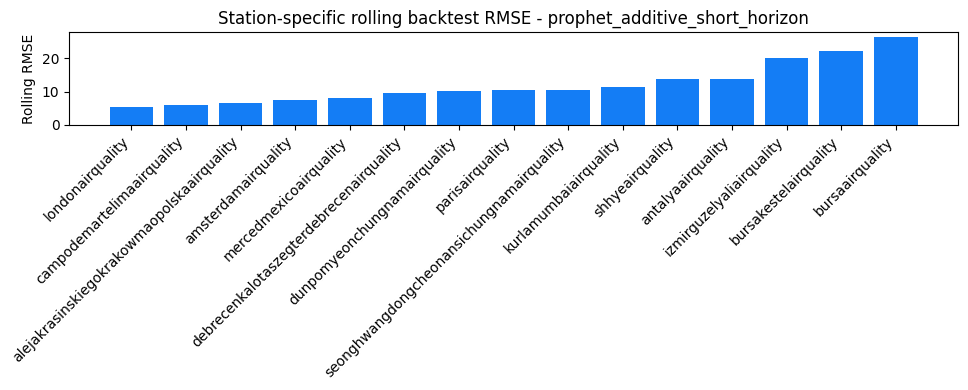

In [17]:
best_station_backtest_df = rolling_station_outputs[best_station_config_name].copy()
display(best_station_backtest_df)

plt.figure(figsize=(10, 4))
plt.bar(best_station_backtest_df['station_key'], best_station_backtest_df['mean_rmse'], color='#147df5')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Rolling RMSE')
plt.title(f'Station-specific rolling backtest RMSE - {best_station_config_name}')
plt.tight_layout()
plt.show()


## 5H. Holdout Error Breakdown and High-Pollution Stress Test

Before changing features or model families, we inspect where the current champion is still struggling.

We summarize errors by station and by calendar month, then isolate high-pollution days so the next optimization pass can target the weakest segments first.

This is the section to watch when overall RMSE looks good but the model may still be weak on the most operationally important pollution spikes.

The current stress-focused features and weights were chosen directly from this breakdown, especially the worst stations and winter/high-pollution combinations.

,station_key,rows,mean_actual,MAE,RMSE
0,izmirguzelyaliairquality,114,114.438596,35.674615,42.798097
1,kurlamumbaiairquality,281,102.298932,16.096536,26.631644
2,izmirkarsiyakaairquality,52,151.057692,19.638087,24.435402
3,bursakestelairquality,259,79.625483,16.968102,22.565028
4,antalyaairquality,189,74.730159,14.857143,17.842888
5,bursaairquality,169,84.982249,12.274706,17.520380
6,shhyeairquality,253,58.407115,10.389164,14.788063
7,debrecenkalotaszegterdebrecenairquality,534,57.307116,8.642612,13.679337
8,dunpomyeonchungnamairquality,583,67.751286,9.707023,13.018974
9,seonghwangdongcheonansichungnamairquality,593,60.124789,8.297893,10.889330


,month,rows,mean_actual,MAE,RMSE
10,2025-04,146,67.828767,7.173503,9.511870
11,2025-05,156,63.237179,7.163385,9.198881
12,2025-06,171,55.742690,6.653325,9.050670
13,2025-07,124,55.806452,6.910575,8.800518
14,2025-08,155,53.580645,7.206774,8.934637
15,2025-09,223,51.820628,6.642570,8.743891
16,2025-10,219,57.570776,8.193813,11.248676
17,2025-11,266,82.665414,11.699662,15.868515
18,2025-12,306,92.509804,13.327976,18.283860
19,2026-01,274,81.919708,13.712256,20.167651


,segment,rows,mean_actual,MAE,RMSE
0,all_days,4149,71.024584,10.649211,16.274952
1,high_pollution_days,2694,87.945434,12.228285,18.279428
2,lower_pollution_days,1455,39.694845,7.725480,11.688867


,station_key,rows,mean_actual,MAE,RMSE
0,izmirguzelyaliairquality,99,125.262626,39.402991,45.659601
1,kurlamumbaiairquality,251,110.211155,16.474219,27.491172
2,izmirkarsiyakaairquality,52,151.057692,19.638087,24.435402
3,debrecenkalotaszegterdebrecenairquality,222,83.418919,12.945563,19.121325
4,bursakestelairquality,179,96.162011,14.477888,18.995676
5,antalyaairquality,146,85.109589,16.117995,18.788783
6,bursaairquality,124,100.943548,12.261368,18.428342
7,londonairquality,47,73.617021,11.017018,16.082341
8,shhyeairquality,123,78.772358,10.512380,14.919019
9,dunpomyeonchungnamairquality,353,86.943343,11.400757,14.688248


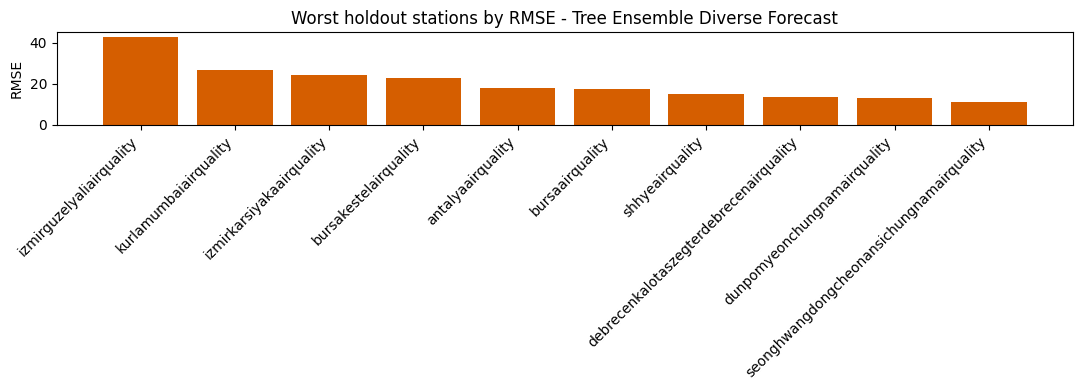

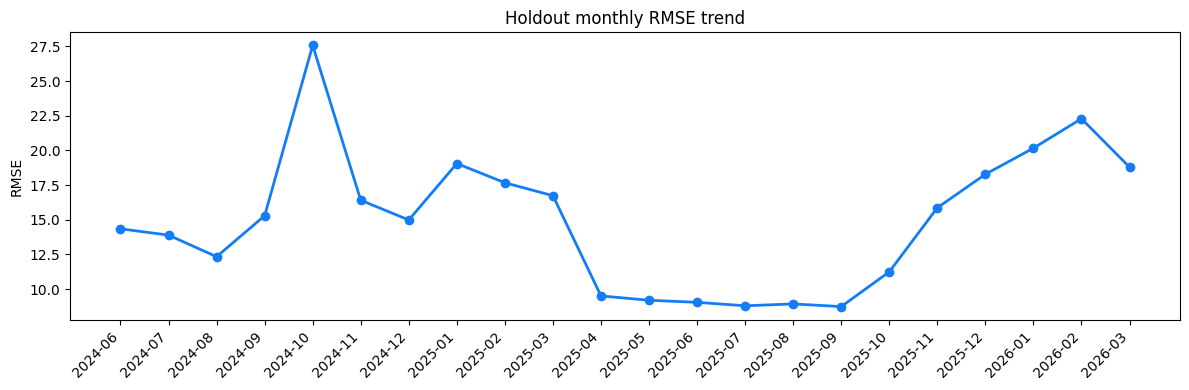

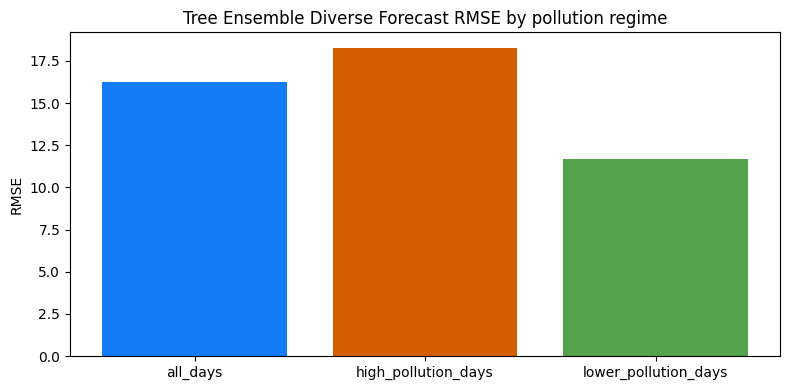

In [18]:
error_breakdown_df = selected_model_df[['ds', 'station_key', 'y', 'yhat']].copy()
error_breakdown_df['abs_error'] = (error_breakdown_df['y'] - error_breakdown_df['yhat']).abs()
error_breakdown_df['squared_error'] = (error_breakdown_df['y'] - error_breakdown_df['yhat']) ** 2
error_breakdown_df['month'] = error_breakdown_df['ds'].dt.to_period('M').astype(str)
error_breakdown_df['high_pollution_flag'] = (error_breakdown_df['y'] >= 55).astype(int)

station_error_df = error_breakdown_df.groupby('station_key').agg(
    rows=('abs_error', 'size'),
    mean_actual=('y', 'mean'),
    MAE=('abs_error', 'mean'),
    RMSE=('squared_error', lambda s: np.sqrt(s.mean())),
).sort_values(['RMSE', 'MAE'], ascending=False).reset_index()

month_error_df = error_breakdown_df.groupby('month').agg(
    rows=('abs_error', 'size'),
    mean_actual=('y', 'mean'),
    MAE=('abs_error', 'mean'),
    RMSE=('squared_error', lambda s: np.sqrt(s.mean())),
).sort_values('month').reset_index()

segment_metrics_rows = []
for segment_name, segment_df in {
    'all_days': error_breakdown_df,
    'high_pollution_days': error_breakdown_df[error_breakdown_df['high_pollution_flag'] == 1].copy(),
    'lower_pollution_days': error_breakdown_df[error_breakdown_df['high_pollution_flag'] == 0].copy(),
}.items():
    if segment_df.empty:
        continue
    segment_metrics_rows.append({
        'segment': segment_name,
        'rows': int(len(segment_df)),
        'mean_actual': float(segment_df['y'].mean()),
        'MAE': float(segment_df['abs_error'].mean()),
        'RMSE': float(np.sqrt(segment_df['squared_error'].mean())),
    })
segment_metrics_df = pd.DataFrame(segment_metrics_rows)

high_pollution_station_error_df = error_breakdown_df[error_breakdown_df['high_pollution_flag'] == 1].groupby('station_key').agg(
    rows=('abs_error', 'size'),
    mean_actual=('y', 'mean'),
    MAE=('abs_error', 'mean'),
    RMSE=('squared_error', lambda s: np.sqrt(s.mean())),
).sort_values(['RMSE', 'MAE'], ascending=False).reset_index()

display(station_error_df.head(10))
display(month_error_df.tail(12))
display(segment_metrics_df)
display(high_pollution_station_error_df.head(10))

plt.figure(figsize=(11, 4))
plt.bar(station_error_df.head(10)['station_key'], station_error_df.head(10)['RMSE'], color='#d55e00')
plt.xticks(rotation=45, ha='right')
plt.ylabel('RMSE')
plt.title(f'Worst holdout stations by RMSE - {selected_plot_label}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(month_error_df['month'], month_error_df['RMSE'], marker='o', linewidth=2, color='#147df5')
plt.xticks(rotation=45, ha='right')
plt.ylabel('RMSE')
plt.title('Holdout monthly RMSE trend')
plt.tight_layout()
plt.show()

if not segment_metrics_df.empty:
    plt.figure(figsize=(8, 4))
    plt.bar(segment_metrics_df['segment'], segment_metrics_df['RMSE'], color=['#147df5', '#d55e00', '#54a24b'][:len(segment_metrics_df)])
    plt.ylabel('RMSE')
    plt.title(f'{selected_plot_label} RMSE by pollution regime')
    plt.tight_layout()
    plt.show()


## 6. Visual Diagnostics

These plots help verify whether the champion is tracking real movement or just looking good in aggregate metrics.

Read these charts together:
- the holdout error views show where the champion still fails
- the final diagnostic plots show whether the forecast shape is believable station by station


,ds,station_key,y,yhat,yhat_lower,yhat_upper,abs_error
583,2024-10-01,kurlamumbaiairquality,409.0,101.352337,101.352337,101.352337,307.647663
885,2024-11-20,bursakestelairquality,33.0,150.708973,150.708973,150.708973,117.708973
1272,2025-01-22,bursaairquality,276.0,159.855920,159.855920,159.855920,116.144080
619,2024-10-07,debrecenkalotaszegterdebrecenairquality,142.0,27.969340,27.969340,27.969340,114.030660
3815,2026-02-16,izmirguzelyaliairquality,163.0,54.571593,54.571593,54.571593,108.428407
3663,2026-01-31,izmirguzelyaliairquality,158.0,64.142722,64.142722,64.142722,93.857278
590,2024-10-02,kurlamumbaiairquality,116.0,208.681276,208.681276,208.681276,92.681276
130,2024-07-15,bursakestelairquality,167.0,79.716177,79.716177,79.716177,87.283823
3648,2026-01-30,izmirguzelyaliairquality,161.0,75.534653,75.534653,75.534653,85.465347
3001,2025-11-22,shhyeairquality,5.0,88.363421,88.363421,88.363421,83.363421


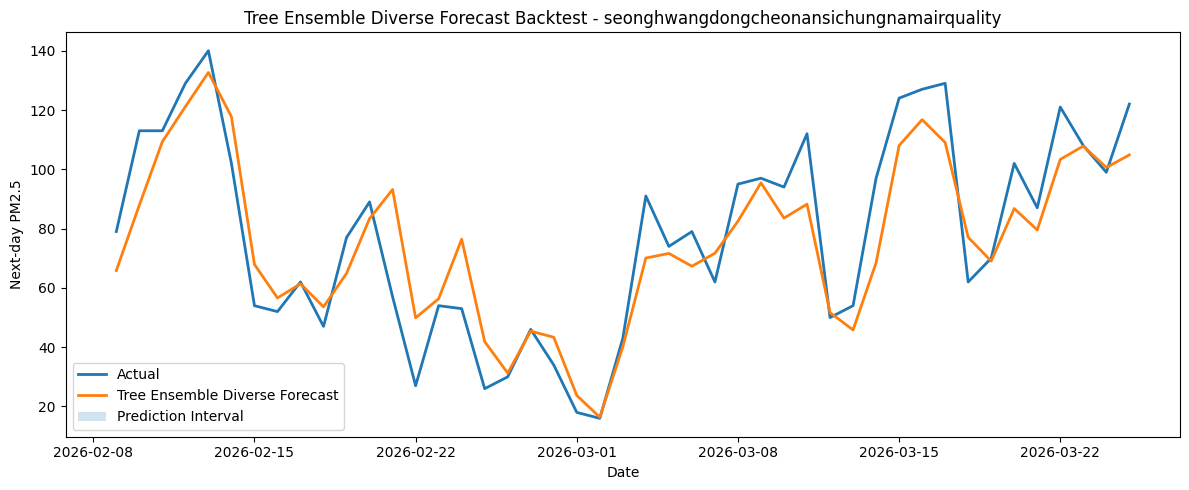

In [19]:
plot_df = selected_model_df.copy()
plot_label = selected_plot_label
plot_df['abs_error'] = (plot_df['y'] - plot_df['yhat']).abs()

display(plot_df.sort_values('abs_error', ascending=False).head(10))

sample_station = plot_df['station_key'].mode().iloc[0]
station_plot = plot_df[plot_df['station_key'] == sample_station].tail(45)

plt.figure(figsize=(12, 5))
plt.plot(station_plot['ds'], station_plot['y'], label='Actual', linewidth=2)
plt.plot(station_plot['ds'], station_plot['yhat'], label=plot_label, linewidth=2)
plt.fill_between(
    station_plot['ds'],
    station_plot['yhat_lower'],
    station_plot['yhat_upper'],
    alpha=0.2,
    label='Prediction Interval',
)
plt.title(f'{plot_label} Backtest - {sample_station}')
plt.xlabel('Date')
plt.ylabel('Next-day PM2.5')
plt.legend()
plt.tight_layout()
plt.show()


## 7. Save Champion and Prophet Artifacts

We save two artifacts here:
- the Prophet reference model used in the notebook flow
- the actual champion model selected by the tournament

This keeps the notebook useful for both backward compatibility and production-facing champion tracking.

At this stage the artifact we care about most is the current tree-based champion, not the Prophet reference model.


In [20]:
prophet_model_path = ARTIFACT_DIR / 'pm25_next_day_prophet.json'
champion_model_path = ARTIFACT_DIR / f"pm25_next_day_{best_model_name}.pkl"
metrics_path = ARTIFACT_DIR / 'pm25_next_day_forecast_metrics.json'
station_order = model_df['station_key'].astype(str).drop_duplicates().tolist() if 'station_key' in model_df.columns else []
date_reference_col = 'ds' if 'ds' in model_df.columns else 'date'
dataset_start_date = str(pd.to_datetime(model_df[date_reference_col]).min().date()) if date_reference_col in model_df.columns else ''

prophet_model_path.write_text(model_to_json(prophet_model), encoding='utf-8')

champion_model_obj = prophet_model if best_model_name == 'prophet_regressor_model' else model_tournament_results.get(best_model_name, {}).get('model')
if champion_model_obj is not None:
    with open(champion_model_path, 'wb') as f:
        pickle.dump(champion_model_obj, f)

if isinstance(champion_model_obj, dict) and champion_model_obj.get('type') == 'weighted_ensemble':
    for component_name in champion_model_obj.get('components', []):
        component_obj = model_tournament_results.get(component_name, {}).get('model')
        component_path = ARTIFACT_DIR / f"pm25_next_day_{component_name}.pkl"
        if component_obj is not None:
            with open(component_path, 'wb') as f:
                pickle.dump(component_obj, f)

payload = {
    'model_type': 'ChampionAwareBundle',
    'target': 'pm25_next_day',
    'feature_cols': feature_cols,
    'tree_feature_cols': tree_feature_cols,
    'station_order': station_order,
    'dataset_start_date': dataset_start_date,
    'worst_station_keys': sorted(worst_station_keys),
    'high_pollution_threshold': 55.0,
    'train_rows': int(len(train_df)),
    'test_rows': int(len(test_df)),
    'best_model_name': best_model_name,
    'champion_model_path': str(champion_model_path),
    'prophet_model_path': str(prophet_model_path),
    'best_prophet_candidate': best_prophet_name,
    'best_prophet_config': best_prophet_config,
    'prophet_tuning_results': tuning_results_df.to_dict(orient='records'),
    'model_tournament_results': tournament_preview_df.to_dict(orient='records'),
    'top_tree_tuning_results': top_tree_tuning_df.to_dict(orient='records'),
    'rolling_summary': rolling_summary_df.to_dict(orient='records'),
    'selected_station_config': best_station_config_name,
    'baseline_metrics': baseline_metrics,
    'holt_winters_metrics': holt_metrics,
    'prophet_metrics': prophet_metrics,
    'random_forest_metrics': rf_metrics,
    'ridge_metrics': model_tournament_results['ridge_benchmark']['metrics'],
    'gradient_boosting_metrics': model_tournament_results['gradient_boosting_benchmark']['metrics'],
    'hist_gradient_boosting_metrics': model_tournament_results['hist_gradient_boosting_benchmark']['metrics'],
    'worst_holdout_stations': station_error_df.head(10).to_dict(orient='records'),
    'monthly_holdout_error': month_error_df.to_dict(orient='records'),
    'pollution_segment_metrics': segment_metrics_df.to_dict(orient='records'),
    'high_pollution_station_error': high_pollution_station_error_df.head(10).to_dict(orient='records'),
}
metrics_path.write_text(json.dumps(payload, indent=2), encoding='utf-8')

print('Saved Prophet model to:', prophet_model_path)
print('Saved champion model to:', champion_model_path)
print('Saved metrics to:', metrics_path)


Saved Prophet model to: C:\Users\rbeyz\Desktop\AirPulse_Global\artifacts\pm25_next_day_prophet.json
Saved champion model to: C:\Users\rbeyz\Desktop\AirPulse_Global\artifacts\pm25_next_day_tree_ensemble_diverse.pkl
Saved metrics to: C:\Users\rbeyz\Desktop\AirPulse_Global\artifacts\pm25_next_day_forecast_metrics.json
